In [ ]:
# !pip install --upgrade pandas

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
%cd '/content/drive/My Drive/Colab Notebooks/db'
!ls

/content/drive/My Drive/Colab Notebooks/db
 API_AG.LND.AGRI.K2_DS2_en_csv_v2_716226.csv	  london_merged.csv
 API_AG.LND.FRST.K2_DS2_en_csv_v2_716262.csv	  Meteorite_Landings.csv
 API_EG.USE.ELEC.KH.PC_DS2_en_csv_v2_715482.csv   poblacion.csv
 API_EN.ATM.CO2E.KT_DS2_en_csv_v2_713263.csv	  test.csv
 API_SP.POP.TOTL_DS2_en_csv_v2_713131.csv	  test.hdf
 covid_19_data.csv				  test.json
 covid.csv					  test.parquet
 flights.db					  test.pkl
 GlobalLandTemperaturesByCountry.csv		  test.xlsx
'london_merged (1).csv'


In [ ]:
%matplotlib inline
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

## Se lee el archivo csv guardado previamente en Drive en este caso y se muestra

## **_Recuerden_**: El argumento que recibe el método es la ruta del archivo, si este esta en la misma carpeta , basta solo el nombre y su respectiva extensión

In [ ]:
# https://www.kaggle.com/code/ashfakyeafi/london-bike-share-prophet-xgb-lstm de este link sale ese archivo london_merged.csv
dflmerged = pd.read_csv('/content/drive/My Drive/Colab Notebooks/db/london_merged.csv')
dflmerged

,timestamp,cnt,t1,t2,hum,wind_speed,weather_code,is_holiday,is_weekend,season
0,2015-01-04 00:00:00,182,3.0,2.0,93.0,6.0,3.0,0.0,1.0,3.0
1,2015-01-04 01:00:00,138,3.0,2.5,93.0,5.0,1.0,0.0,1.0,3.0
2,2015-01-04 02:00:00,134,2.5,2.5,96.5,0.0,1.0,0.0,1.0,3.0
3,2015-01-04 03:00:00,72,2.0,2.0,100.0,0.0,1.0,0.0,1.0,3.0
4,2015-01-04 04:00:00,47,2.0,0.0,93.0,6.5,1.0,0.0,1.0,3.0
...,...,...,...,...,...,...,...,...,...,...
17409,2017-01-03 19:00:00,1042,5.0,1.0,81.0,19.0,3.0,0.0,0.0,3.0
17410,2017-01-03 20:00:00,541,5.0,1.0,81.0,21.0,4.0,0.0,0.0,3.0
17411,2017-01-03 21:00:00,337,5.5,1.5,78.5,24.0,4.0,0.0,0.0,3.0
17412,2017-01-03 22:00:00,224,5.5,1.5,76.0,23.0,4.0,0.0,0.0,3.0


/tmp/ipykernel_5367/2616245338.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  x.set_xticklabels(["Spring", "Summer", "Fall", "Winter"])


Text(0.5, 1.0, 'Renta de bicicletas por temporada')

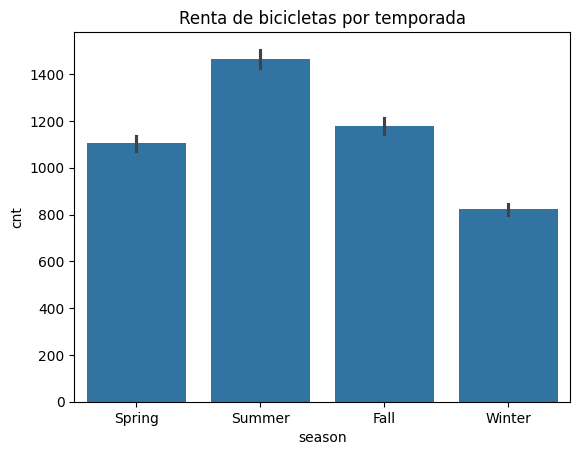

In [ ]:
import seaborn as sns

x = sns.barplot(x="season", y="cnt", data=dflmerged)
x.set_xticklabels(["Spring", "Summer", "Fall", "Winter"])
x.set_title("Renta de bicicletas por temporada")


In [ ]:
# dflmerged[dflmerged["t1"]==1]
dflmerged[dflmerged["t1"]>=10].iloc[:10,2]

,t1
36,10.0
37,10.0
38,10.0
39,10.0
40,10.0
58,10.0
59,10.0
60,11.0
86,10.0
90,10.0


In [ ]:
df_lmerged=dflmerged.copy()
df_lmerged

,timestamp,cnt,t1,t2,hum,wind_speed,weather_code,is_holiday,is_weekend,season
0,2015-01-04 00:00:00,182,3.0,2.0,93.0,6.0,3.0,0.0,1.0,3.0
1,2015-01-04 01:00:00,138,3.0,2.5,93.0,5.0,1.0,0.0,1.0,3.0
2,2015-01-04 02:00:00,134,2.5,2.5,96.5,0.0,1.0,0.0,1.0,3.0
3,2015-01-04 03:00:00,72,2.0,2.0,100.0,0.0,1.0,0.0,1.0,3.0
4,2015-01-04 04:00:00,47,2.0,0.0,93.0,6.5,1.0,0.0,1.0,3.0
...,...,...,...,...,...,...,...,...,...,...
17409,2017-01-03 19:00:00,1042,5.0,1.0,81.0,19.0,3.0,0.0,0.0,3.0
17410,2017-01-03 20:00:00,541,5.0,1.0,81.0,21.0,4.0,0.0,0.0,3.0
17411,2017-01-03 21:00:00,337,5.5,1.5,78.5,24.0,4.0,0.0,0.0,3.0
17412,2017-01-03 22:00:00,224,5.5,1.5,76.0,23.0,4.0,0.0,0.0,3.0


## Se muestra el tipo de variables que compone el dataframe



In [ ]:
# df_lmerged.dtypes
df_lmerged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17414 entries, 0 to 17413
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   timestamp     17414 non-null  object 
 1   cnt           17414 non-null  int64  
 2   t1            17414 non-null  float64
 3   t2            17414 non-null  float64
 4   hum           17414 non-null  float64
 5   wind_speed    17414 non-null  float64
 6   weather_code  17414 non-null  float64
 7   is_holiday    17414 non-null  float64
 8   is_weekend    17414 non-null  float64
 9   season        17414 non-null  float64
dtypes: float64(8), int64(1), object(1)
memory usage: 1.3+ MB


La columna timestamp esta como _tipo object_ ,es modificada a otro tipo datetime, el cual es reconocido por pandas.

In [ ]:
df_lmerged['timestamp'] = pd.to_datetime(df_lmerged['timestamp'])
df_lmerged['timestamp']


,timestamp
0,2015-01-04 00:00:00
1,2015-01-04 01:00:00
2,2015-01-04 02:00:00
3,2015-01-04 03:00:00
4,2015-01-04 04:00:00
...,...
17409,2017-01-03 19:00:00
17410,2017-01-03 20:00:00
17411,2017-01-03 21:00:00
17412,2017-01-03 22:00:00


Creacion de una nueva columna

In [ ]:
df_lmerged.describe()

,timestamp,cnt,t1,t2,hum,wind_speed,weather_code,is_holiday,is_weekend,season
count,17414,17414.000000,17414.000000,17414.000000,17414.000000,17414.000000,17414.000000,17414.000000,17414.000000,17414.000000
mean,2016-01-03 22:31:00.571953664,1143.101642,12.468091,11.520836,72.324954,15.913063,2.722752,0.022051,0.285403,1.492075
min,2015-01-04 00:00:00,0.000000,-1.500000,-6.000000,20.500000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,2015-07-04 20:15:00,257.000000,8.000000,6.000000,63.000000,10.000000,1.000000,0.000000,0.000000,0.000000
50%,2016-01-03 15:30:00,844.000000,12.500000,12.500000,74.500000,15.000000,2.000000,0.000000,0.000000,1.000000
75%,2016-07-04 15:45:00,1671.750000,16.000000,16.000000,83.000000,20.500000,3.000000,0.000000,1.000000,2.000000
max,2017-01-03 23:00:00,7860.000000,34.000000,34.000000,100.000000,56.500000,26.000000,1.000000,1.000000,3.000000
std,NaN,1085.108068,5.571818,6.615145,14.313186,7.894570,2.341163,0.146854,0.451619,1.118911


<Axes: >

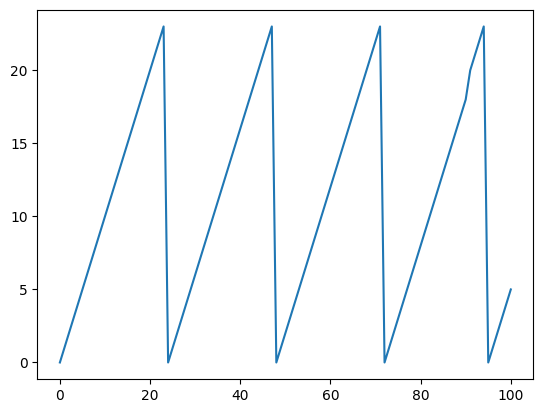

In [ ]:
df_lmerged['timestamp'] = pd.to_datetime(df_lmerged['timestamp'])
df_lmerged['hour'] = df_lmerged['timestamp'].dt.hour
df_lmerged.loc[:100,"hour"].plot()

Los objetos dataframes y series cuenta con una amplia posiblidad de gráficos modificando el el argumento kind[texto del vínculo](https:// https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.plot.html#pandas.DataFrame.plot)




In [ ]:
df_lmerged.set_index(["timestamp","season"],inplace=True)
df_lmerged.head(10)

,,cnt,t1,t2,hum,wind_speed,weather_code,is_holiday,is_weekend,hour
timestamp,season,,,,,,,,,
2015-01-04 00:00:00,3.0,182,3.0,2.0,93.0,6.0,3.0,0.0,1.0,0
2015-01-04 01:00:00,3.0,138,3.0,2.5,93.0,5.0,1.0,0.0,1.0,1
2015-01-04 02:00:00,3.0,134,2.5,2.5,96.5,0.0,1.0,0.0,1.0,2
2015-01-04 03:00:00,3.0,72,2.0,2.0,100.0,0.0,1.0,0.0,1.0,3
2015-01-04 04:00:00,3.0,47,2.0,0.0,93.0,6.5,1.0,0.0,1.0,4
2015-01-04 05:00:00,3.0,46,2.0,2.0,93.0,4.0,1.0,0.0,1.0,5
2015-01-04 06:00:00,3.0,51,1.0,-1.0,100.0,7.0,4.0,0.0,1.0,6
2015-01-04 07:00:00,3.0,75,1.0,-1.0,100.0,7.0,4.0,0.0,1.0,7
2015-01-04 08:00:00,3.0,131,1.5,-1.0,96.5,8.0,4.0,0.0,1.0,8


In [ ]:
display(df_lmerged.loc["2015-01",["wind_speed","hour"]].head(20))
# display(df_lmerged.loc["2015-01",["wind_speed","hour"]].tail(20))
# df_lmerged.loc["2015":"2016",["wind_speed","hour"]]

,,wind_speed,hour
timestamp,season,,
2015-01-04 00:00:00,3.0,6.0,0
2015-01-04 01:00:00,3.0,5.0,1
2015-01-04 02:00:00,3.0,0.0,2
2015-01-04 03:00:00,3.0,0.0,3
2015-01-04 04:00:00,3.0,6.5,4
2015-01-04 05:00:00,3.0,4.0,5
2015-01-04 06:00:00,3.0,7.0,6
2015-01-04 07:00:00,3.0,7.0,7
2015-01-04 08:00:00,3.0,8.0,8


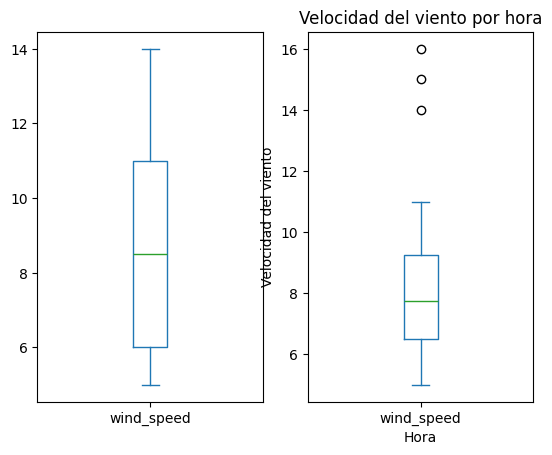

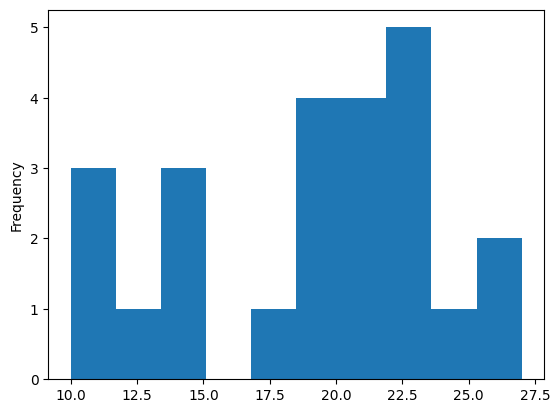

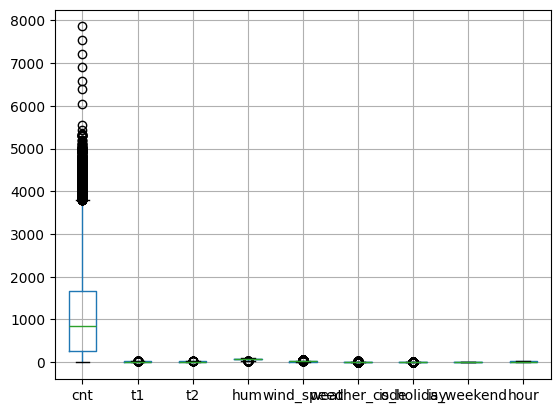

In [ ]:
f,(a1,a2)=plt.subplots(1,2)
x=df_lmerged['wind_speed'].loc["2015-01-05"].plot(kind="box",ax=a1)
x=df_lmerged['wind_speed'].loc["2016-01-05"].plot(kind="box",ax=a2)
x.set_xlabel("Hora")
x.set_ylabel("Velocidad del viento")
x.set_title("Velocidad del viento por hora")
plt.show()
df_lmerged['wind_speed'].loc["2017-01-03"].plot(kind="hist",x="wind_speed",y="hour")
plt.show()
df_lmerged.boxplot()
plt.show()

In [ ]:
df = df_lmerged.iloc[:, 0:]
df

,,cnt,t1,t2,hum,wind_speed,weather_code,is_holiday,is_weekend,hour
timestamp,season,,,,,,,,,
2015-01-04 00:00:00,3.0,182,3.0,2.0,93.0,6.0,3.0,0.0,1.0,0
2015-01-04 01:00:00,3.0,138,3.0,2.5,93.0,5.0,1.0,0.0,1.0,1
2015-01-04 02:00:00,3.0,134,2.5,2.5,96.5,0.0,1.0,0.0,1.0,2
2015-01-04 03:00:00,3.0,72,2.0,2.0,100.0,0.0,1.0,0.0,1.0,3
2015-01-04 04:00:00,3.0,47,2.0,0.0,93.0,6.5,1.0,0.0,1.0,4
...,...,...,...,...,...,...,...,...,...,...
2017-01-03 19:00:00,3.0,1042,5.0,1.0,81.0,19.0,3.0,0.0,0.0,19
2017-01-03 20:00:00,3.0,541,5.0,1.0,81.0,21.0,4.0,0.0,0.0,20
2017-01-03 21:00:00,3.0,337,5.5,1.5,78.5,24.0,4.0,0.0,0.0,21


In [ ]:
np.sin(df['wind_speed']**2) + 10

,,wind_speed
timestamp,season,
2015-01-04 00:00:00,3.0,9.008221
2015-01-04 01:00:00,3.0,9.867648
2015-01-04 02:00:00,3.0,10.000000
2015-01-04 03:00:00,3.0,10.000000
2015-01-04 04:00:00,3.0,9.013013
...,...,...
2017-01-03 19:00:00,3.0,10.279387
2017-01-03 20:00:00,3.0,10.923470
2017-01-03 21:00:00,3.0,9.114047


In [ ]:
df["resultadot1t2"]=df['t1']-df['t2']
df

,,cnt,t1,t2,hum,wind_speed,weather_code,is_holiday,is_weekend,hour,resultadot1t2
timestamp,season,,,,,,,,,,
2015-01-04 00:00:00,3.0,182,3.0,2.0,93.0,6.0,3.0,0.0,1.0,0,1.0
2015-01-04 01:00:00,3.0,138,3.0,2.5,93.0,5.0,1.0,0.0,1.0,1,0.5
2015-01-04 02:00:00,3.0,134,2.5,2.5,96.5,0.0,1.0,0.0,1.0,2,0.0
2015-01-04 03:00:00,3.0,72,2.0,2.0,100.0,0.0,1.0,0.0,1.0,3,0.0
2015-01-04 04:00:00,3.0,47,2.0,0.0,93.0,6.5,1.0,0.0,1.0,4,2.0
...,...,...,...,...,...,...,...,...,...,...,...
2017-01-03 19:00:00,3.0,1042,5.0,1.0,81.0,19.0,3.0,0.0,0.0,19,4.0
2017-01-03 20:00:00,3.0,541,5.0,1.0,81.0,21.0,4.0,0.0,0.0,20,4.0
2017-01-03 21:00:00,3.0,337,5.5,1.5,78.5,24.0,4.0,0.0,0.0,21,4.0


In [ ]:
df['t1'].iloc[::3].sub(df['t2'], fill_value = "1000")

,,0
timestamp,season,
2015-01-04 00:00:00,3.0,1.0
2015-01-04 01:00:00,3.0,997.5
2015-01-04 02:00:00,3.0,997.5
2015-01-04 03:00:00,3.0,0.0
2015-01-04 04:00:00,3.0,1000.0
...,...,...
2017-01-03 19:00:00,3.0,4.0
2017-01-03 20:00:00,3.0,999.0
2017-01-03 21:00:00,3.0,998.5




```
+    add()
-    sub(), subtract()
*    mul(), multiply()
/    truediv(), div(), divide()
//   floordiv()
%    mod()
**   pow()
```



In [ ]:
df['t1']/df['t2']

,,0
timestamp,season,
2015-01-04 00:00:00,3.0,1.500000
2015-01-04 01:00:00,3.0,1.200000
2015-01-04 02:00:00,3.0,1.000000
2015-01-04 03:00:00,3.0,1.000000
2015-01-04 04:00:00,3.0,inf
...,...,...
2017-01-03 19:00:00,3.0,5.000000
2017-01-03 20:00:00,3.0,5.000000
2017-01-03 21:00:00,3.0,3.666667


In [ ]:
df['t1'].dot(df['t1']) # Operacion producto punto

3247652.777777778

In [ ]:
def fun_1(x):
  y = x**2 + 1
  return y

In [ ]:
fun_1(10)

101

In [ ]:
np.arange(-5,6)

array([-5, -4, -3, -2, -1,  0,  1,  2,  3,  4,  5])

In [ ]:
np.arange(-5,6).shape

(11,)

In [ ]:
fun_1(np.arange(-5,6))

array([26, 17, 10,  5,  2,  1,  2,  5, 10, 17, 26])

In [ ]:
df

,,cnt,t1,t2,hum,wind_speed,weather_code,is_holiday,is_weekend,resultadot1t2
timestamp,season,,,,,,,,,
2015-01-04 00:00:00,3.0,182,3.0,2.0,93.0,6.0,3.0,0.0,1.0,1.0
2015-01-04 01:00:00,3.0,138,3.0,2.5,93.0,5.0,1.0,0.0,1.0,NaN
2015-01-04 02:00:00,3.0,134,2.5,2.5,96.5,0.0,1.0,0.0,1.0,NaN
2015-01-04 03:00:00,3.0,72,2.0,2.0,100.0,0.0,1.0,0.0,1.0,0.0
2015-01-04 04:00:00,3.0,47,2.0,0.0,93.0,6.5,1.0,0.0,1.0,NaN
...,...,...,...,...,...,...,...,...,...,...
2017-01-03 19:00:00,3.0,1042,5.0,1.0,81.0,19.0,3.0,0.0,0.0,4.0
2017-01-03 20:00:00,3.0,541,5.0,1.0,81.0,21.0,4.0,0.0,0.0,NaN
2017-01-03 21:00:00,3.0,337,5.5,1.5,78.5,24.0,4.0,0.0,0.0,NaN


In [ ]:
def fun_2(x, a=1, b=0):
  y = x**2 + a*x + b
  return y

In [ ]:
fun_2(10, a = 20, b= -100)

200

In [ ]:
df['cnt'].apply(fun_2, args = (20, -100))

,,cnt
timestamp,season,
2015-01-04 00:00:00,3.0,36664
2015-01-04 01:00:00,3.0,21704
2015-01-04 02:00:00,3.0,20536
2015-01-04 03:00:00,3.0,6524
2015-01-04 04:00:00,3.0,3049
...,...,...
2017-01-03 19:00:00,3.0,1106504
2017-01-03 20:00:00,3.0,303401
2017-01-03 21:00:00,3.0,120209


In [ ]:
df['cnt'].apply(fun_2, a =20, b= -100)

timestamp            season
2015-01-04 00:00:00  3.0         36664
2015-01-04 01:00:00  3.0         21704
2015-01-04 02:00:00  3.0         20536
2015-01-04 03:00:00  3.0          6524
2015-01-04 04:00:00  3.0          3049
                                ...   
2017-01-03 19:00:00  3.0       1106504
2017-01-03 20:00:00  3.0        303401
2017-01-03 21:00:00  3.0        120209
2017-01-03 22:00:00  3.0         54556
2017-01-03 23:00:00  3.0         22001
Name: cnt, Length: 17414, dtype: int64

In [ ]:
df['t1'].apply(lambda x: x+273)

timestamp            season
2015-01-04 00:00:00  3.0       276.0
2015-01-04 01:00:00  3.0       276.0
2015-01-04 02:00:00  3.0       275.5
2015-01-04 03:00:00  3.0       275.0
2015-01-04 04:00:00  3.0       275.0
                               ...  
2017-01-03 19:00:00  3.0       278.0
2017-01-03 20:00:00  3.0       278.0
2017-01-03 21:00:00  3.0       278.5
2017-01-03 22:00:00  3.0       278.5
2017-01-03 23:00:00  3.0       278.0
Name: t1, Length: 17414, dtype: float64

In [ ]:
df

,,cnt,t1,t2,hum,wind_speed,weather_code,is_holiday,is_weekend,hour
timestamp,season,,,,,,,,,
2015-01-04 00:00:00,3.0,182,3.0,2.0,93.0,6.0,3.0,0.0,1.0,0
2015-01-04 01:00:00,3.0,138,3.0,2.5,93.0,5.0,1.0,0.0,1.0,1
2015-01-04 02:00:00,3.0,134,2.5,2.5,96.5,0.0,1.0,0.0,1.0,2
2015-01-04 03:00:00,3.0,72,2.0,2.0,100.0,0.0,1.0,0.0,1.0,3
2015-01-04 04:00:00,3.0,47,2.0,0.0,93.0,6.5,1.0,0.0,1.0,4
...,...,...,...,...,...,...,...,...,...,...
2017-01-03 19:00:00,3.0,1042,5.0,1.0,81.0,19.0,3.0,0.0,0.0,19
2017-01-03 20:00:00,3.0,541,5.0,1.0,81.0,21.0,4.0,0.0,0.0,20
2017-01-03 21:00:00,3.0,337,5.5,1.5,78.5,24.0,4.0,0.0,0.0,21


In [ ]:
df.apply(lambda x: x.mean(),axis=0) # A lo largo de cada columna ,  ya que por defecto axis = 0

,0
cnt,1143.101642
t1,12.468091
t2,11.520836
hum,72.324954
wind_speed,15.913063
weather_code,2.722752
is_holiday,0.022051
is_weekend,0.285403
hour,11.513265


In [ ]:
df.apply(lambda x: x.mean(), axis=0) # Camiando axis = 1 , el promdio se aplica a lo largo de las filas

,0
cnt,1143.101642
t1,12.468091
t2,11.520836
hum,72.324954
wind_speed,15.913063
weather_code,2.722752
is_holiday,0.022051
is_weekend,0.285403
hour,11.513265


In [ ]:
df.apply(lambda x: x.std(), axis=1)

,,0
timestamp,season,
2015-01-04 00:00:00,3.0,63.725540
2015-01-04 01:00:00,3.0,51.349294
2015-01-04 02:00:00,3.0,51.128990
2015-01-04 03:00:00,3.0,38.017905
2015-01-04 04:00:00,3.0,32.151983
...,...,...
2017-01-03 19:00:00,3.0,342.961733
2017-01-03 20:00:00,3.0,176.705813
2017-01-03 21:00:00,3.0,109.598922


In [ ]:
df.apply(lambda x: x['t1']-x['t2'], axis=1)

,,0
timestamp,season,
2015-01-04 00:00:00,3.0,1.0
2015-01-04 01:00:00,3.0,0.5
2015-01-04 02:00:00,3.0,0.0
2015-01-04 03:00:00,3.0,0.0
2015-01-04 04:00:00,3.0,2.0
...,...,...
2017-01-03 19:00:00,3.0,4.0
2017-01-03 20:00:00,3.0,4.0
2017-01-03 21:00:00,3.0,4.0


In [ ]:
df.map(lambda x: x/1000)

,cnt,t1,t2,hum,wind_speed,weather_code,is_holiday,is_weekend,season,hour
0,0.182,0.0030,0.0020,0.0930,0.0060,0.003,0.0,0.001,0.003,0.000
1,0.138,0.0030,0.0025,0.0930,0.0050,0.001,0.0,0.001,0.003,0.001
2,0.134,0.0025,0.0025,0.0965,0.0000,0.001,0.0,0.001,0.003,0.002
3,0.072,0.0020,0.0020,0.1000,0.0000,0.001,0.0,0.001,0.003,0.003
4,0.047,0.0020,0.0000,0.0930,0.0065,0.001,0.0,0.001,0.003,0.004
...,...,...,...,...,...,...,...,...,...,...
17409,1.042,0.0050,0.0010,0.0810,0.0190,0.003,0.0,0.000,0.003,0.019
17410,0.541,0.0050,0.0010,0.0810,0.0210,0.004,0.0,0.000,0.003,0.020
17411,0.337,0.0055,0.0015,0.0785,0.0240,0.004,0.0,0.000,0.003,0.021
17412,0.224,0.0055,0.0015,0.0760,0.0230,0.004,0.0,0.000,0.003,0.022


In [ ]:
df

,,cnt,t1,t2,hum,wind_speed,weather_code,is_holiday,is_weekend,resultadot1t2
timestamp,season,,,,,,,,,
2015-01-04 00:00:00,3.0,182,3.0,2.0,93.0,6.0,3.0,0.0,1.0,1.0
2015-01-04 01:00:00,3.0,138,3.0,2.5,93.0,5.0,1.0,0.0,1.0,NaN
2015-01-04 02:00:00,3.0,134,2.5,2.5,96.5,0.0,1.0,0.0,1.0,NaN
2015-01-04 03:00:00,3.0,72,2.0,2.0,100.0,0.0,1.0,0.0,1.0,0.0
2015-01-04 04:00:00,3.0,47,2.0,0.0,93.0,6.5,1.0,0.0,1.0,NaN
...,...,...,...,...,...,...,...,...,...,...
2017-01-03 19:00:00,3.0,1042,5.0,1.0,81.0,19.0,3.0,0.0,0.0,4.0
2017-01-03 20:00:00,3.0,541,5.0,1.0,81.0,21.0,4.0,0.0,0.0,NaN
2017-01-03 21:00:00,3.0,337,5.5,1.5,78.5,24.0,4.0,0.0,0.0,NaN
